In [1]:
import uproot
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import math
import seaborn as sns

In [2]:
# Set the default behavior for saving figures to have a transparent background
plt.rcParams['savefig.transparent'] = True
# Set default font size
plt.rcParams['font.size'] = 15
# Set default width space between subplots
plt.rcParams['figure.subplot.wspace'] = 0.3

In [93]:
#events = uproot.open("/home/nikolay/BMN/tmp/dst_7821_AllSetup.root:bmndata")
events = uproot.open("/home/nikolay/BMN/centrality/prepare_files_MBT.root:bmndata")
#events.show()
#feature_names = np.array(["FHCalEvent/fTotalEnergy", "HodoEvent/fTotalSignal"])
feature_names = np.array(["fFHCal", "fHodo"])
#It is assumed that features are positive -- at clustering stage they will be normalized to [0,1]
nbins = 500
n_clusters = 7
eps = 5e-2 #fluctuations of statistics in event classes
load_model = "results/model.pkl" # "None" if recalculate model

In [16]:
trigger = events["BmnTrigInfo./BmnTrigInfo.fInputsAR"].array(library="np")
bc1s = events["BmnTrigInfo./BmnTrigInfo.fBC1Integral"].array(library="np")
vtxZ = events["PrimaryVertex./PrimaryVertex.fZ"].array(library="np")
vtxNtr = events["PrimaryVertex./PrimaryVertex.fNTracks"].array(library="np")

# Create a dictionary to store selected events
selected_events = {
    "Trigger": trigger,
    "BC1S": bc1s,
    "VertexZ": vtxZ,
    "VertexNTracks": vtxNtr
}

In [4]:
selected_events = {}

In [5]:
features = {}
for feat_name in feature_names:
    features[feat_name] = events[feat_name].array(library="np")
    
# Add other features to the selected events dictionary
for feat_name, feat_data in features.items():
    selected_events[feat_name] = feat_data

In [6]:
# Convert the dictionary to a pandas DataFrame
df = pd.DataFrame(selected_events)

In [6]:
# Extracting individual bits
bitBT = (df["Trigger"].apply(lambda x: (x >> 2) & 1)).astype(bool)
bitMBT = (df["Trigger"].apply(lambda x: (x >> 5) & 1)).astype(bool)
bitNiT = (df["Trigger"].apply(lambda x: (x >> 3) & 1)).astype(bool)
bitCCT1 = (df["Trigger"].apply(lambda x: (x >> 4) & 1)).astype(bool)
bitCCT2 = (df["Trigger"].apply(lambda x: (x >> 7) & 1)).astype(bool)

# Forming boolean conditions
trigBT = (bitBT == 1) & (bitMBT == 0) & (bitCCT1 == 0) & (bitCCT2 == 0)
trigMBT = (bitMBT == 1) & (bitNiT == 0)
trigCCT1 = (bitCCT1 == 1) & (bitMBT == 0) & (bitCCT2 == 0)
trigCCT2 = (bitCCT2 == 1)

# Applying selection based on boolean conditions
df = df[trigMBT]

In [7]:
df = df[
    (df["BC1S"] >= 14000) & (df["BC1S"] <= 40000) &  # BC1S integral
    (abs(df["VertexZ"]) <= 1.5) & (df["VertexNTracks"] > 1)  # Vertex conditions
]
df.reset_index(drop=True, inplace=True)

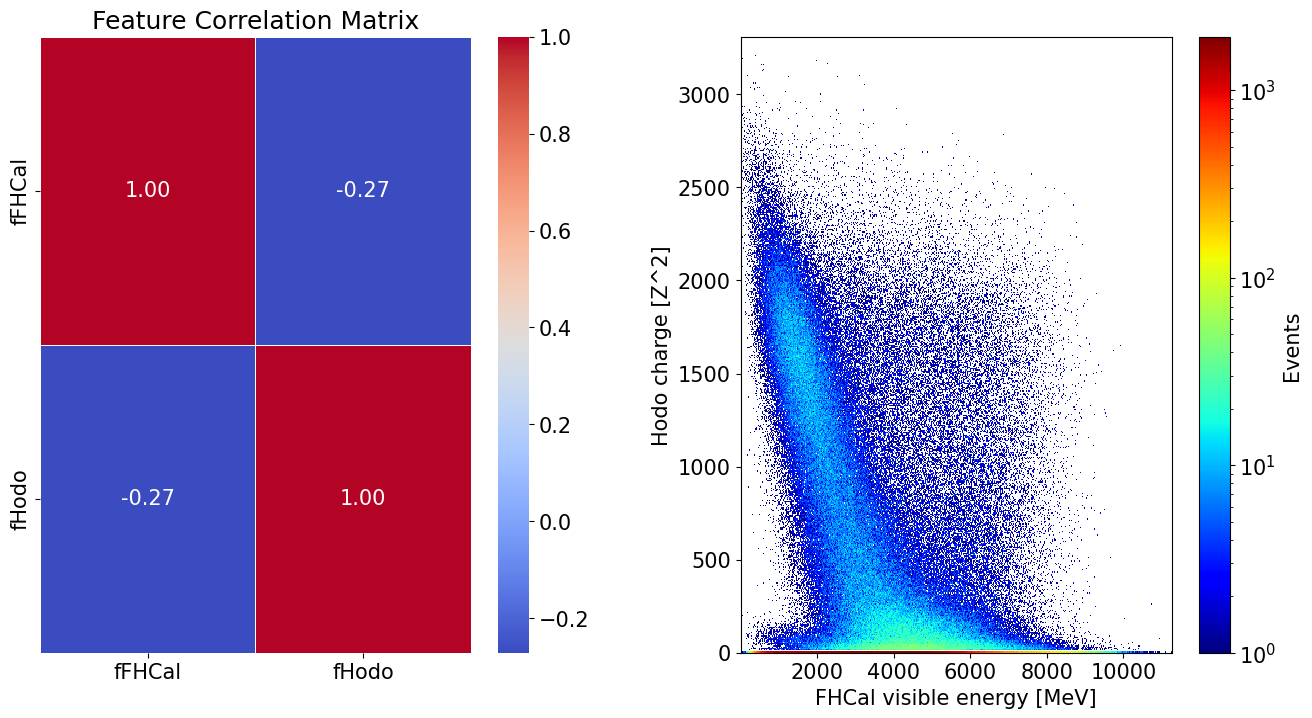

In [7]:
# Define the number of features
combinations = int(np.math.factorial(len(features)) / (2 * np.math.factorial(len(features) - 2)))

# Create a grid of subplots
fig, axes = plt.subplots(1, 1 + combinations, figsize=(8 * (1 + combinations), 8))

# Compute the correlation matrix
corr_matrix = df[feature_names].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, ax=axes[0])
axes[0].set_title('Feature Correlation Matrix')

counter = 1
for i, feature1 in enumerate(features):
    for j, feature2 in enumerate(features):
        if j <= i:
            continue
        ax = axes[counter]
        ax.hist2d(df[feature1], df[feature2], bins=(nbins, nbins), cmap='jet', cmin=1, norm="log")
        #ax.set_xlabel(feature1)
        #ax.set_ylabel(feature2)
        ax.set_xlabel("FHCal visible energy [MeV]")
        ax.set_ylabel("Hodo charge [Z^2]")
        cbar = plt.colorbar(ax.collections[0], ax=ax)
        cbar.set_label('Events', rotation=90)
        counter += 1

plt.savefig('results/correlations.png')

In [153]:
# Determine the maximum value for each feature
max_values = df.max()
podgon = 1.7
max_values['fFHCal'] *= podgon

# Normalize each feature
for feat_name in feature_names:
    df[f'normalized_{feat_name}'] = df[feat_name] / max_values[feat_name]

# Create X using the normalized features
X = df[[f'normalized_{feat_name}' for feat_name in feature_names]].values

In [149]:
n_clusters=5

In [154]:
if True:
    from k_means_constrained import KMeansConstrained
    import pickle

    
    clf = KMeansConstrained(n_clusters=n_clusters, size_min=int(len(X)/n_clusters), size_max=int((1.0+eps)*len(X)/n_clusters), n_jobs=6, init=save)
    clf.fit_predict(X)

/home/nikolay/.local/lib/python3.8/site-packages/k_means_constrained/k_means_constrained_.py:644: RuntimeWarning: Explicit initial center position passed: performing only one init in k-means instead of n_init=10
  k_means_constrained(


In [135]:
if True:
    with open("results/model7cl.pkl", "wb") as f:
        pickle.dump(clf, f)

In [158]:
if True:
    import pickle
    with open("results/model7cl.pkl", "rb") as f:
        clf = pickle.load(f)

In [134]:
label_converter = np.array([4,3,0,6,1,5,2])
print(label_converter)

for event in range(len(clf.labels_)):
    clf.labels_[event] = label_converter[clf.labels_[event]]

[4 3 0 6 1 5 2]


In [152]:
import copy
save = copy.deepcopy(clf.cluster_centers_)

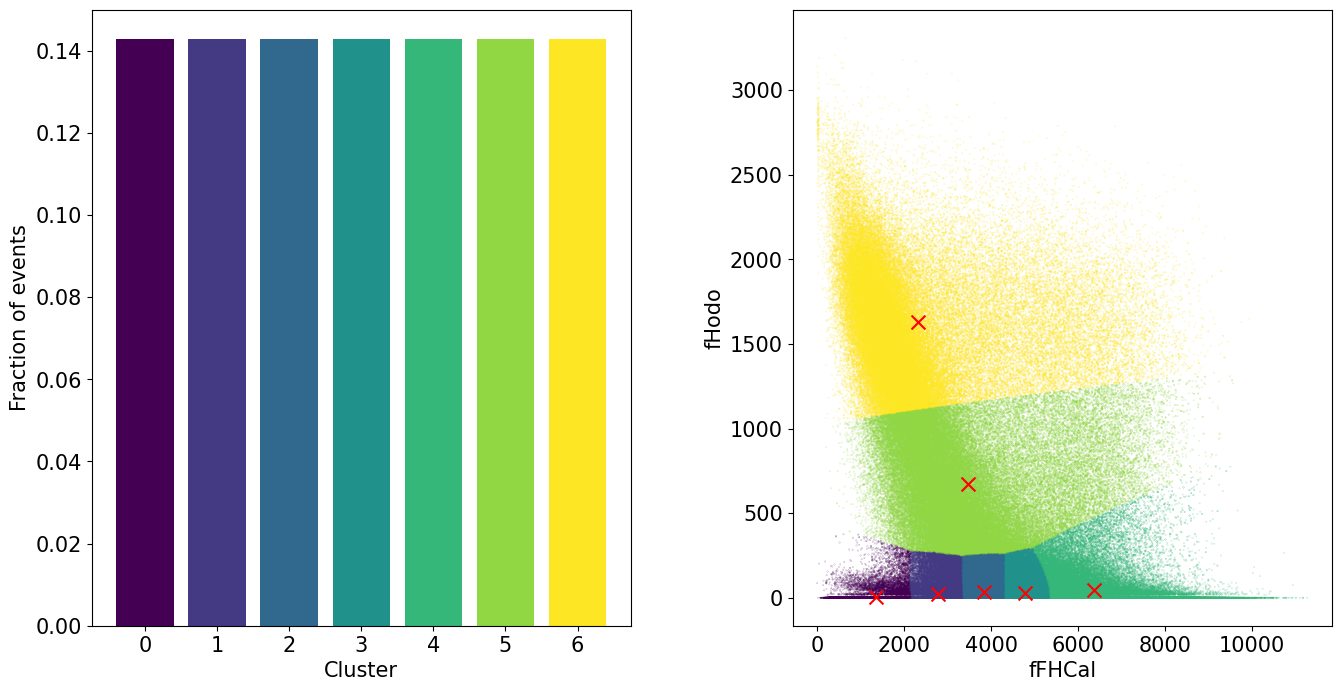

In [164]:
# Create a grid of subplots
fig, axes = plt.subplots(1, 1 + combinations, figsize=(8 * (1 + combinations), 8))

fractions = [np.sum(clf.labels_ == k)/len(X) for k in range(clf.n_clusters)]
colors = [plt.cm.viridis(i) for i in np.linspace(0, 1, clf.n_clusters)]
counts = axes[0].bar(range(clf.n_clusters), fractions, color=colors)
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Fraction of events')

counter = 1
for i, feature1 in enumerate(features):
    for j, feature2 in enumerate(features):
        if j <= i:
            continue
        ax = axes[counter]
        ax.scatter(max_values[feature1] * X[:, i], max_values[feature2] * X[:, j], c=clf.labels_, s=0.01, cmap='viridis')
        ax.scatter(max_values[feature1] * clf.cluster_centers_[:, i],max_values[feature2]*clf.cluster_centers_[:, j], marker='x', color='red', s=100)
        ax.set_xlabel(feature1)
        ax.set_ylabel(feature2)
        counter += 1

plt.savefig('results/clusters.png')

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c1
Info in <TCanvas::Print>: png file results/feature_pdfs.png has been created
Info in <TCanvas::SaveAs>: ROOT file results/feature_pdfs_cc.root has been created


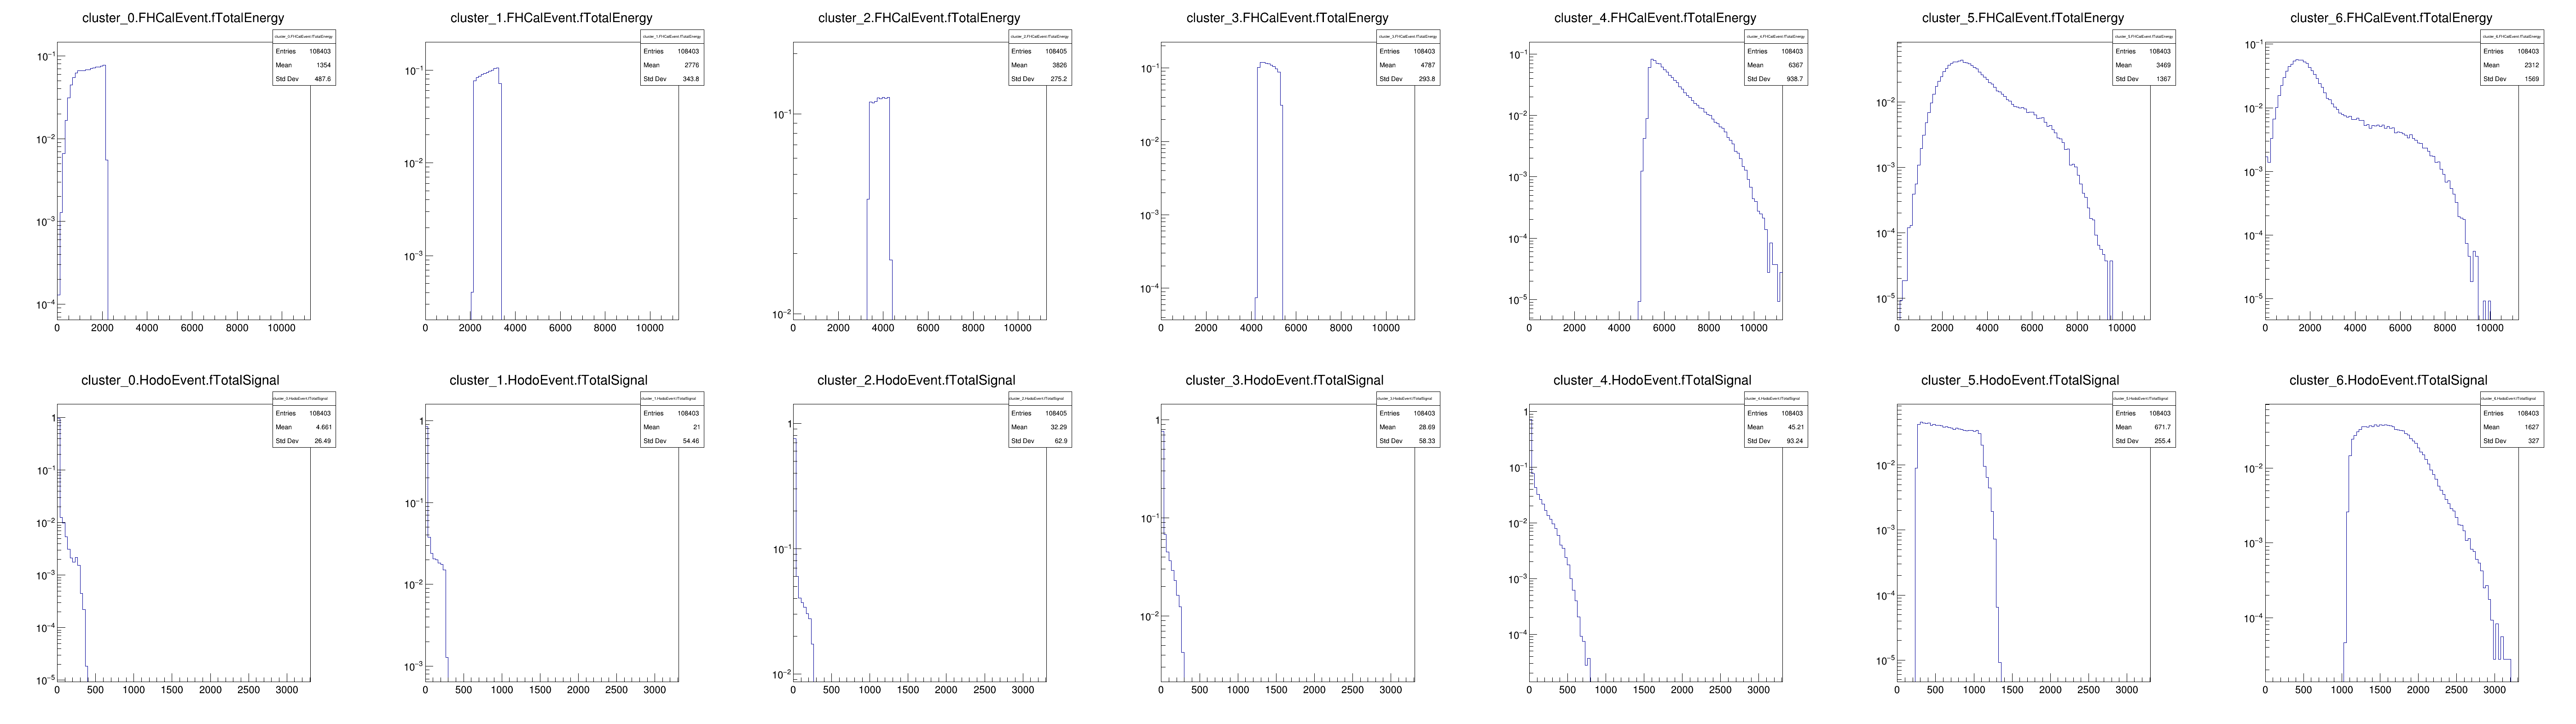

In [136]:
from ROOT import TCanvas, gPad, TH1F, TFile

# Create canvas
c1 = TCanvas('c1', 'Y_distribs_in_classes', 800*n_clusters, 800*len(feature_names))
c1.Divide(n_clusters, len(feature_names))

# Dictionary to store histograms
histos = {}

# Loop over each feature and cluster to create histograms
for feat_name in feature_names:
    for cluster in range(n_clusters):
        if feat_name == 'fHodo':
           hist_name = f"cluster_{cluster}." +  "HodoEvent.fTotalSignal"
        if feat_name == 'fFHCal':
            hist_name = f"cluster_{cluster}." +  "FHCalEvent.fTotalEnergy"
        #hist_name = f"cluster_{cluster}/{feat_name}"
        hist_title = hist_name
        hist = TH1F(hist_name, hist_title, nbins, 0, df[feat_name].max())
        histos[hist_name] = hist

# Fill histograms with data from DataFrame
for event in range(len(df)):
    cluster = clf.labels_[event]
    for feat_name in feature_names:
        #hist_name = f"cluster_{cluster}/{feat_name}"
        if feat_name == 'fHodo':
           hist_name = f"cluster_{cluster}." +  "HodoEvent.fTotalSignal"
        if feat_name == 'fFHCal':
            hist_name = f"cluster_{cluster}." +  "FHCalEvent.fTotalEnergy"
        hist = histos[hist_name]
        hist.Fill(df[feat_name][event])

# Draw histograms on canvas
counter = 0
for feat_name in feature_names:
    for cluster in range(n_clusters):
        c1.cd(counter+1)
        gPad.SetLogy()
        #hist_name = f"cluster_{cluster}/{feat_name}"
        if feat_name == 'fHodo':
           hist_name = f"cluster_{cluster}." +  "HodoEvent.fTotalSignal"
        if feat_name == 'fFHCal':
            hist_name = f"cluster_{cluster}." +  "FHCalEvent.fTotalEnergy"
        hist = histos[hist_name]
        hist.Scale(1./hist.Integral())
        hist.Draw('hist')
        counter += 1

# Save canvas
c1.Draw()
c1.SaveAs("results/feature_pdfs.png")
c1.SaveAs("results/feature_pdfs_cc.root")

root_file = TFile("results/feature_pdfs.root", "RECREATE")
for hist_name in histos:
    hist = histos[hist_name]
    hist.Write()
root_file.Close()

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c1
Info in <TCanvas::Print>: png file results/feature_pdfs.png has been created
Info in <TCanvas::SaveAs>: ROOT file results/feature_pdfs_cc.root has been created


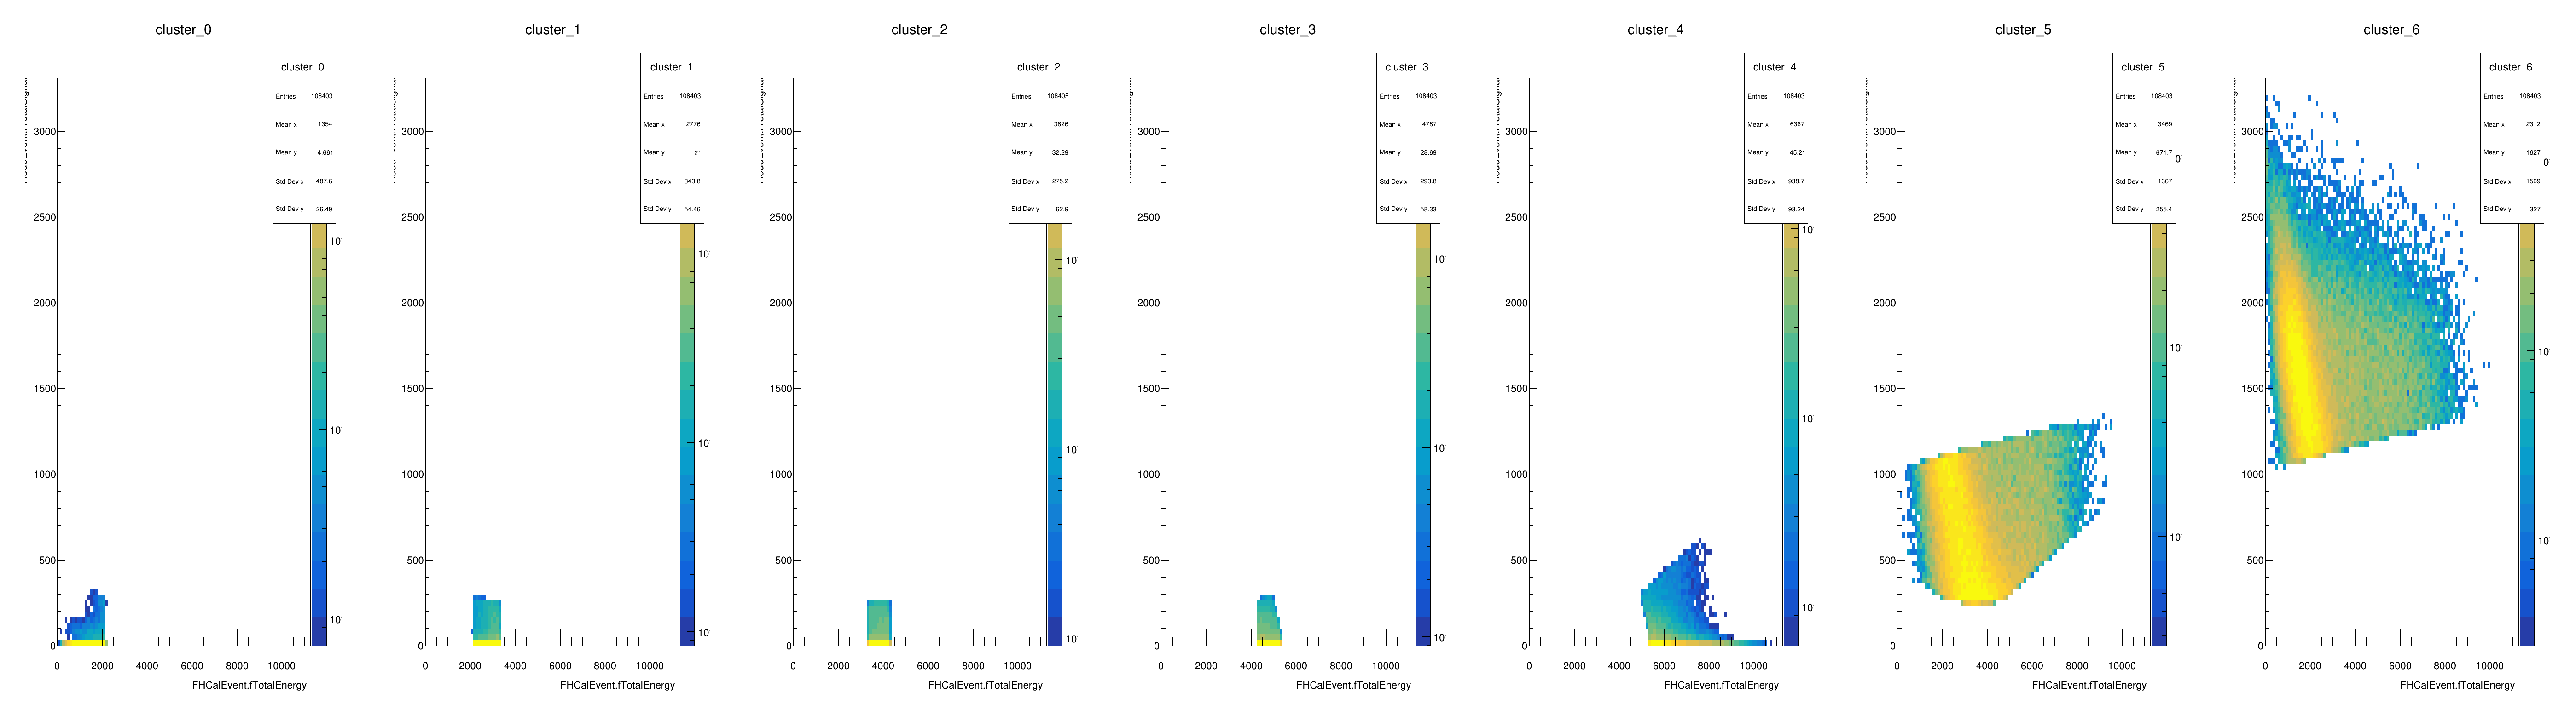

In [137]:
nbins = 100

from ROOT import TCanvas, gPad, TH2F, TH1F, TFile

# Create canvas
c1 = TCanvas('c1', 'Y_distribs_in_classes', 800*n_clusters, 800*len(feature_names))
c1.Divide(n_clusters, 1)

# Dictionary to store histograms
histos = {}

# Loop over each feature and cluster to create histograms
for cluster in range(n_clusters):
    hist_name = f"cluster_{cluster}"
    #hist_name = f"cluster_{cluster}/{feat_name}"
    hist_title = hist_name  + "; FHCalEvent.fTotalEnergy ; HodoEvent.fTotalSignal"
    hist = TH2F(hist_name, hist_title, nbins, 0, df["fFHCal"].max(), nbins, 0, df["fHodo"].max())
    histos[hist_name] = hist

# Fill histograms with data from DataFrame
for event in range(len(df)):
    cluster = clf.labels_[event]      
    hist_name = f"cluster_{cluster}"
    hist = histos[hist_name]
    hist.Fill(df["fFHCal"][event], df["fHodo"][event])

# Draw histograms on canvas
counter = 0
for cluster in range(n_clusters):
    c1.cd(counter+1)
    gPad.SetLogz()
    hist_name = f"cluster_{cluster}"
    hist = histos[hist_name]
    hist.Scale(1./hist.Integral())
    hist.Draw('colz')
    counter += 1

# Save canvas
c1.Draw()
c1.SaveAs("results/feature_pdfs.png")
c1.SaveAs("results/feature_pdfs_cc.root")

root_file = TFile("results/feature_pdfs.root", "RECREATE")
for hist_name in histos:
    hist = histos[hist_name]
    hist.Write()
root_file.Close()